# Walmart Weekly Sales Forecasting using ARIMA & Prophet

In [1]:
# Importing necessary libraries

# Data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker

import warnings
warnings.filterwarnings('ignore')
import math

# Time Series Analysis libraries
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

### Data Loading

In [2]:
df = pd.read_csv("Walmart.csv")

In [3]:
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (6435, 8)


In [4]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [5]:
df.dtypes

Store             int64
Date             object
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object

In [6]:
# Covert Date column
df['Date'] = pd.to_datetime(df['Date'], format = "%d-%m-%Y")

In [7]:
# Verifying the result
df.dtypes

Store                    int64
Date            datetime64[ns]
Weekly_Sales           float64
Holiday_Flag             int64
Temperature            float64
Fuel_Price             float64
CPI                    float64
Unemployment           float64
dtype: object

In [8]:
print(f"Shape of the dataset: {df.shape}")
print(f"Columns of the dataset: {df.columns.values}")
print(f"Total number of stores: {df['Store'].nunique()}")
print(f"Date Range in the dataset: {df['Date'].min().strftime("%d-%m-%Y")} to {df['Date'].max().strftime("%d-%m-%Y")}")
print(f"Total Weeks in the dataset: {df['Date'].nunique()}")
print(f"Total Records: {len(df):,}")
print(f"Average records per store: {len(df) / df['Store'].nunique()}")

Shape of the dataset: (6435, 8)
Columns of the dataset: ['Store' 'Date' 'Weekly_Sales' 'Holiday_Flag' 'Temperature' 'Fuel_Price'
 'CPI' 'Unemployment']
Total number of stores: 45
Date Range in the dataset: 05-02-2010 to 26-10-2012
Total Weeks in the dataset: 143
Total Records: 6,435
Average records per store: 143.0


* There are 45 Walmart stores in consideration.
* The date range is from 2010 to 2012 covering 143 weeks.
* There are 6435 records which is equal to 143 x 45.
* 143 records per store without gaps. 

### Data Cleaning

In [9]:
# Checking duplicates (Before Cleaning)
df.duplicated().value_counts() / len(df) * 100

False    100.0
Name: count, dtype: float64

The False count is 100% meaning that there are no duplicate values in the dataset. 

In [10]:
# Checking missing values (Before Cleaning)
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

There are no missing values in the dataset. 

In [11]:
columns = df.columns.values
print(f"Columns in the dataset: {columns}")

# Checking each column for outliers (Before Cleaning)
for c in columns:
    print(f"\nColumn: {c}")
    print(df[c].value_counts())

Columns in the dataset: ['Store' 'Date' 'Weekly_Sales' 'Holiday_Flag' 'Temperature' 'Fuel_Price'
 'CPI' 'Unemployment']

Column: Store
Store
1     143
24    143
26    143
27    143
28    143
29    143
30    143
31    143
32    143
33    143
34    143
35    143
36    143
37    143
38    143
39    143
40    143
41    143
42    143
43    143
44    143
25    143
23    143
2     143
22    143
3     143
4     143
5     143
6     143
7     143
8     143
9     143
10    143
11    143
12    143
13    143
14    143
15    143
16    143
17    143
18    143
19    143
20    143
21    143
45    143
Name: count, dtype: int64

Column: Date
Date
2010-02-05    45
2011-12-23    45
2011-11-11    45
2011-11-18    45
2011-11-25    45
              ..
2011-01-07    45
2011-01-14    45
2011-01-21    45
2011-01-28    45
2012-10-26    45
Name: count, Length: 143, dtype: int64

Column: Weekly_Sales
Weekly_Sales
1643690.90    1
446751.45     1
1332261.01    1
1366193.35    1
1384870.51    1
             ..
551799.

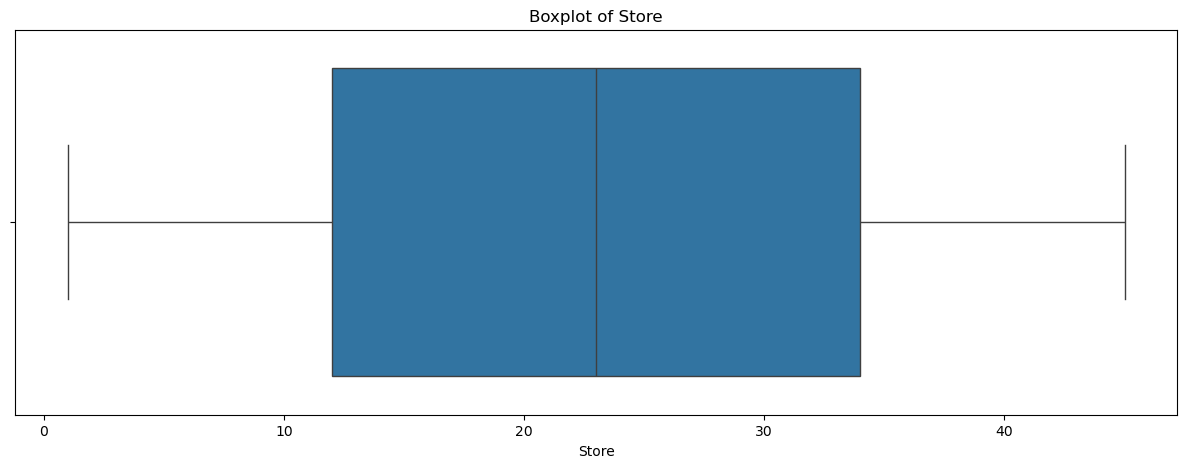

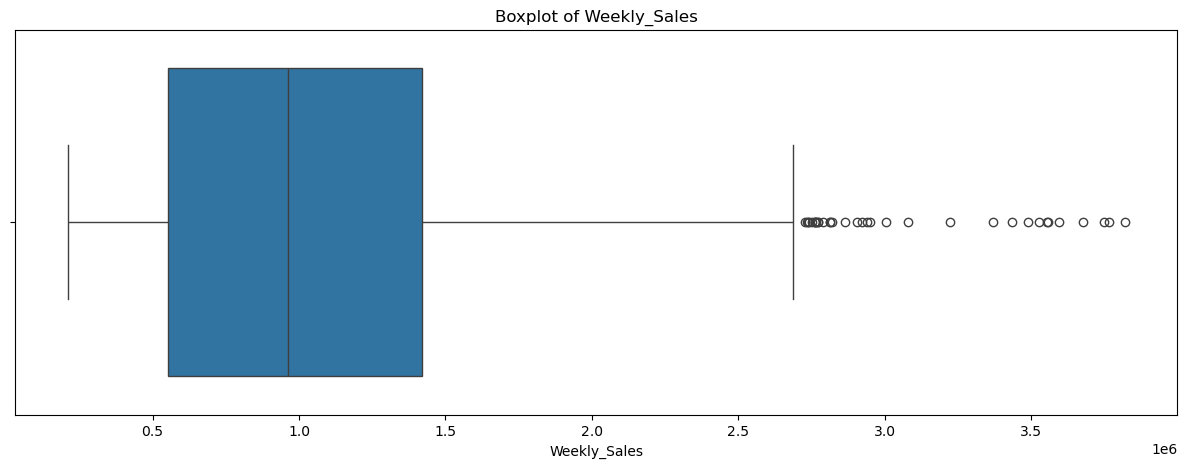

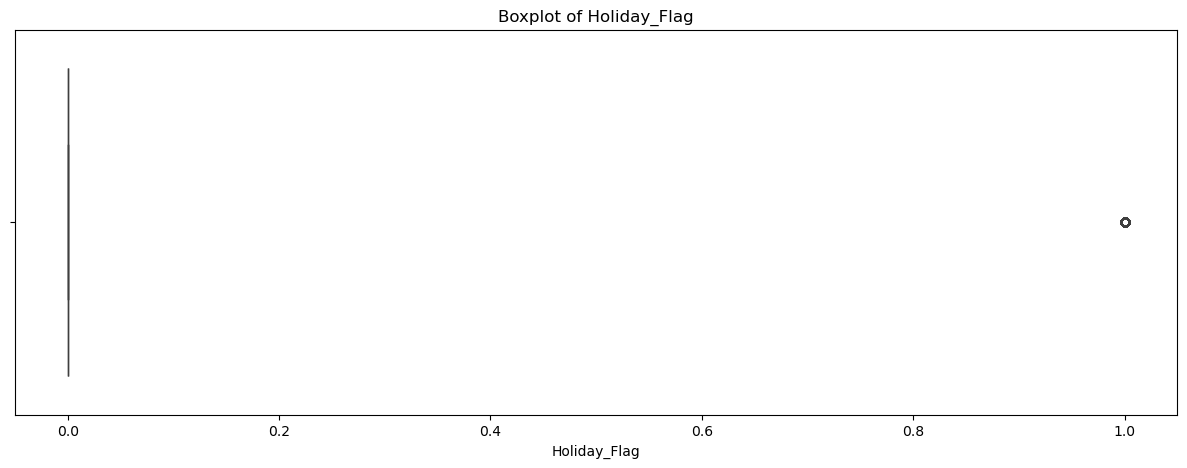

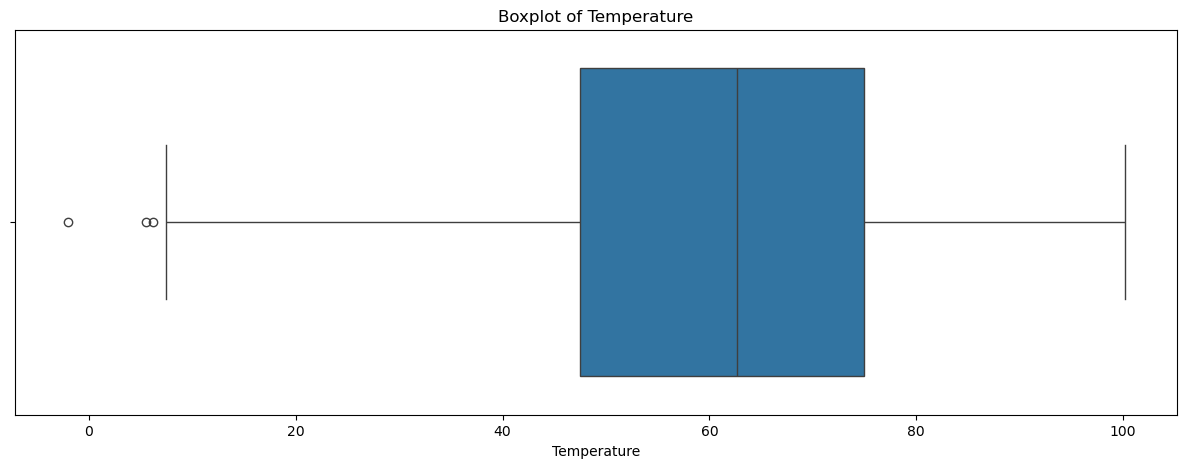

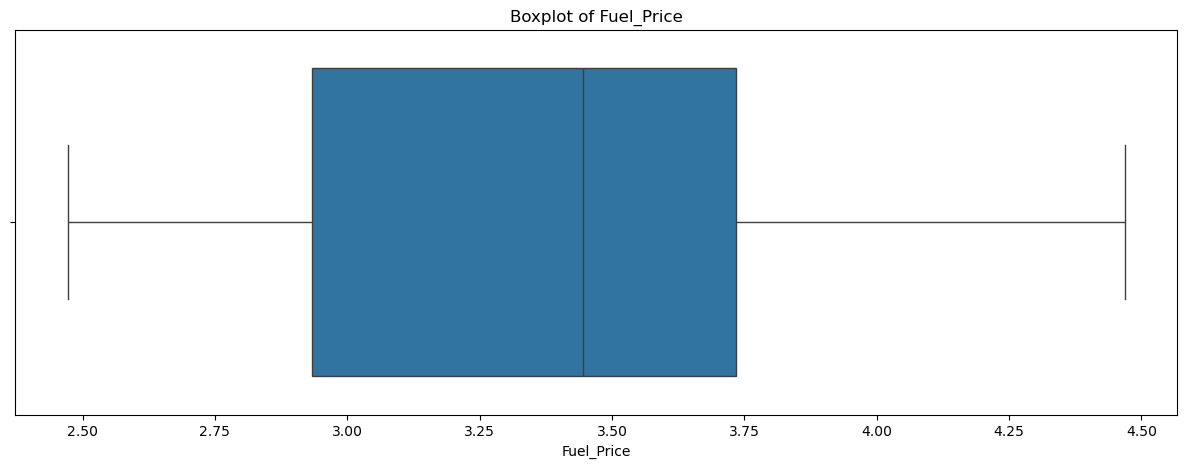

In [12]:
# Checking outliers for numerical columns through boxplots (Before Cleaning)

numerical_cols = ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price']

for col in numerical_cols:
    plt.figure(figsize = (15,5))  # Creates a new window for each plot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

No outliers found in the dataset.

### Exploratory Data Analysis (EDA)

In [13]:
# Top performing stores

pd.options.display.float_format = '{:.0f}'.format
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending = False).reset_index()
store_sales.rename(columns = {'Weekly_Sales': 'Total_Sales'}, inplace = True)
store_sales['Store'] = 'Store ' + store_sales['Store'].astype(str)
top_10_store_sales = store_sales.head(10)
print("The top 10 Stores by Total Sales")
for _, row in top_10_store_sales.iterrows():
    print(f"{row['Store']}: ${row['Total_Sales']:,.0f}")

The top 10 Stores by Total Sales
Store 20: $301,397,792
Store 4: $299,543,953
Store 14: $288,999,911
Store 13: $286,517,704
Store 2: $275,382,441
Store 10: $271,617,714
Store 27: $253,855,917
Store 6: $223,756,131
Store 1: $222,402,809
Store 39: $207,445,542


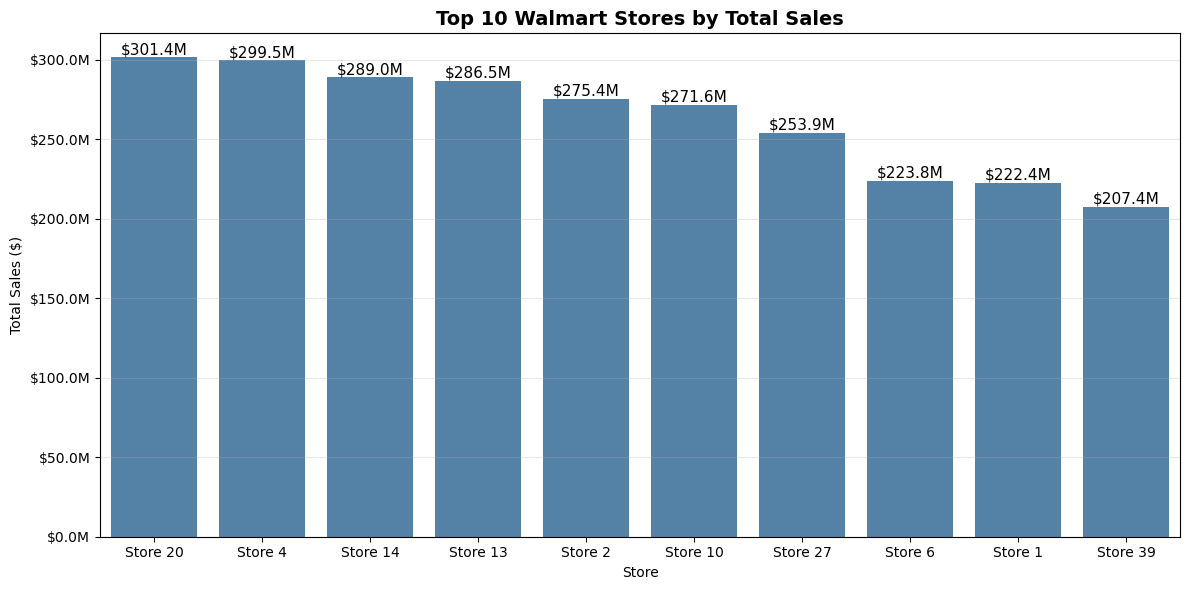

In [14]:
plt.figure(figsize = (12, 6))
bars = sns.barplot(data = top_10_store_sales, x = 'Store', y = 'Total_Sales', color = 'steelblue', order = top_10_store_sales['Store'])
plt.title("Top 10 Walmart Stores by Total Sales", fontsize = 14, fontweight = 'bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e6):.1f}M'))
plt.ylabel("Total Sales ($)")

for p in bars.patches:
    value = f'${p.get_height()/1e6:.1f}M'
    bars.annotate(
        value,
        (p.get_x() + p.get_width() / 2, p.get_height()),  # 3% up from base
        ha='center', va='bottom',
        fontsize=11, color='black'
    )
    
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

- The above graph shows the top performing Walmart stores.
- **Store 20** leads the chart with $300M in total sales followed by Stores 4, 14, 13 and 2. 

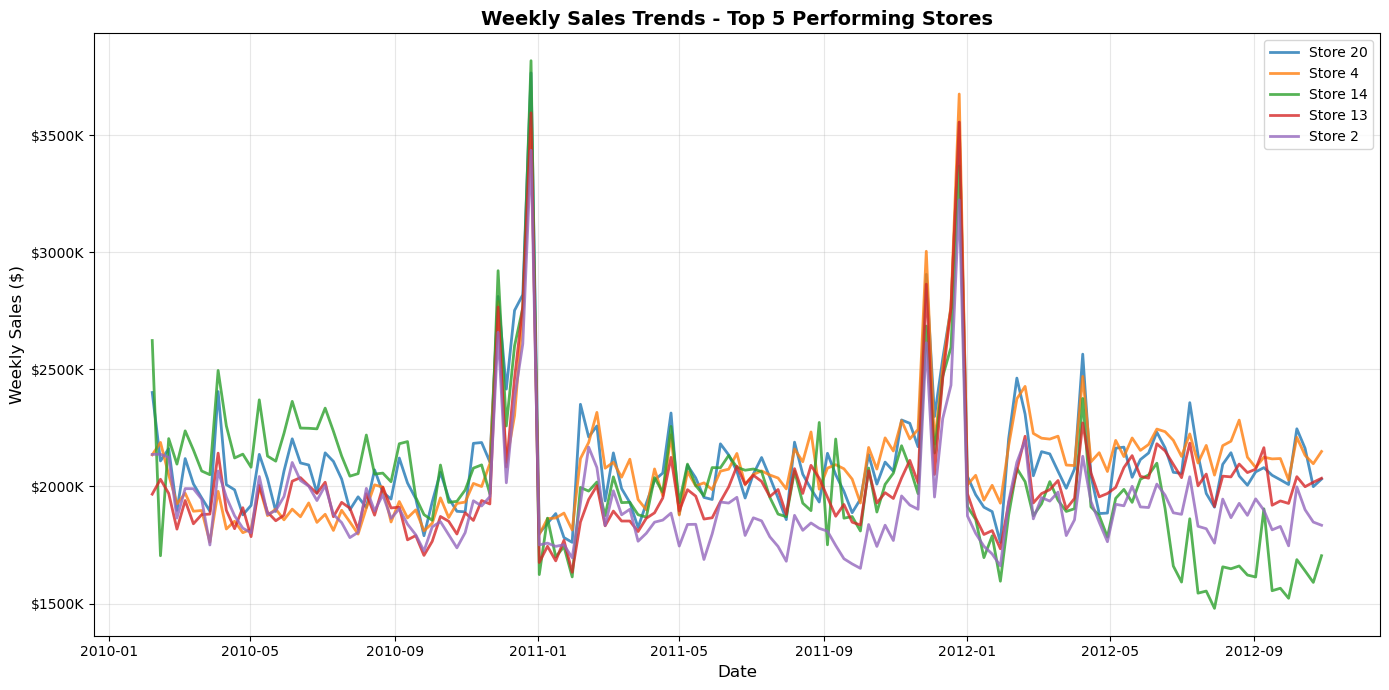

In [15]:
# Store-wise sales over time
df_indexed = df.set_index('Date')
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending = False)
top_5_stores = store_sales.head(5).index

plt.figure(figsize=(14, 7))
for store in top_5_stores:
    store_data = df_indexed[df_indexed['Store'] == store]['Weekly_Sales'].resample('W').sum()
    plt.plot(store_data.index, store_data.values, label=f'Store {store}', linewidth=2, alpha=0.8)

plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.title('Weekly Sales Trends - Top 5 Performing Stores', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All the top performing stores show similar patterns overall.
Spikes are seen around holiday periods (late 2010 and late 2011) indicating seasonality.

In [16]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

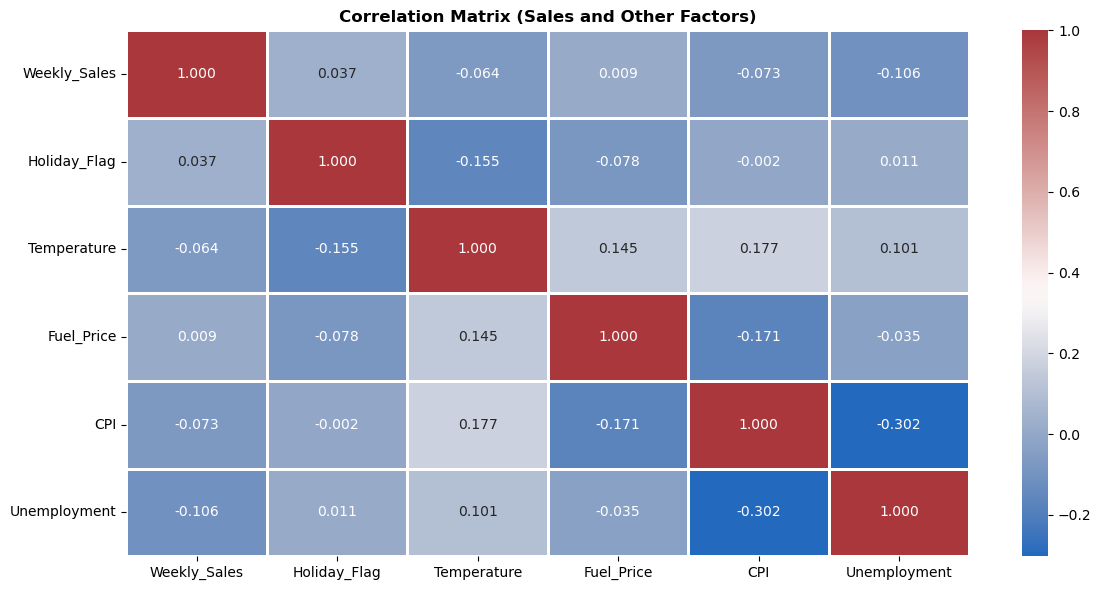

In [19]:
# Correlation Analysis (Impact of different features on Weekly_Sales)

corr_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize = (12, 6))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = '.3f',
    cmap = 'vlag',
    linewidths = 1,
)

plt.title("Correlation Matrix (Sales and Other Factors)", fontweight = 'bold')
plt.tight_layout()
plt.show()

Correlation with Weekly Sales

1. Holiday_Flag : +0.037
2. Fuel Price   : +0.009
3. Temperature  : -0.04
4. CPI          : -0.073
5. Unemployment : -0.106

- Only **Holiday_Flag** seems to have a slight positive correlation with Weekly Sales meaning that sales increase during holiday periods.
- Rest of the factors (Temperature, Fuel Price, CPI and Unemployment) have little to no impact on the sales as they have weak correlation with sales. 

 Average Weekly sales during holidays: $1,122,887.89
 Average Weekly sales during non-holidays: $1,041,256.38
 Boost during holidays: +7.84%


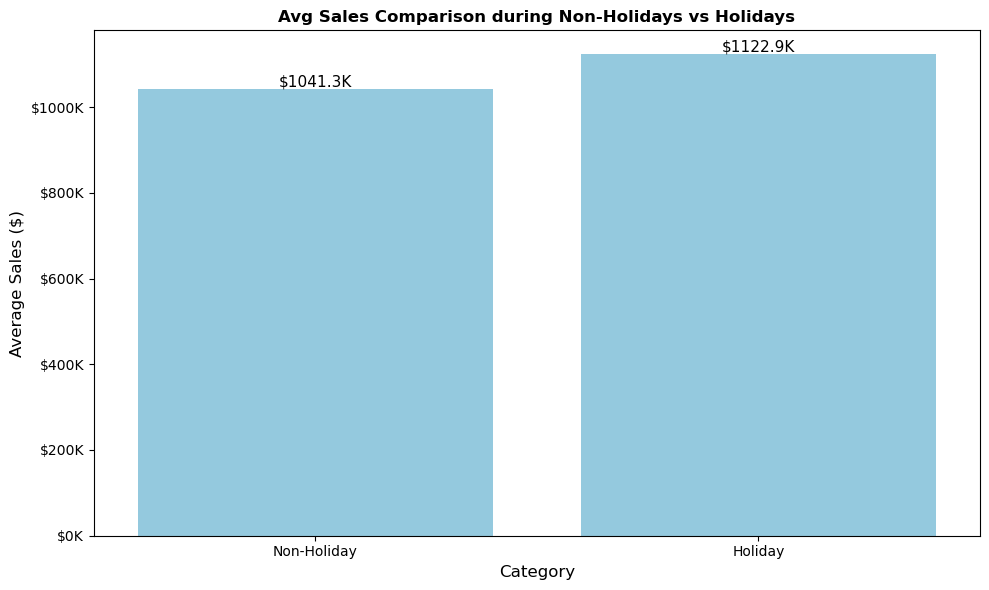

In [20]:
# Holiday-based Analysis with Weekly Sales

holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales']
non_holiday_sales = df[df['Holiday_Flag'] == 0]['Weekly_Sales']
holiday_mean = holiday_sales.mean()
non_holiday_mean = non_holiday_sales.mean()
percent_boost = ((holiday_mean - non_holiday_mean)/non_holiday_mean) * 100
print(f" Average Weekly sales during holidays: ${holiday_mean:,.2f}")
print(f" Average Weekly sales during non-holidays: ${non_holiday_mean:,.2f}")
print(f" Boost during holidays: {percent_boost:+.2f}%")

holiday_df = pd.DataFrame({
    'Category': ['Non-Holiday', 'Holiday'],
    'Average_Sales': [non_holiday_mean, holiday_mean]
})
plt.figure(figsize = (10, 6))
bars = sns.barplot(data = holiday_df, x = 'Category', y = 'Average_Sales', color = 'skyblue')
plt.title("Avg Sales Comparison during Non-Holidays vs Holidays", fontweight = 'bold')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))

for p in bars.patches:
    value = f'${p.get_height()/1e3:.1f}K'
    bars.annotate(
        value,
        (p.get_x() + p.get_width() / 2, p.get_height()),  # 3% up from base
        ha='center', va='bottom', fontsize=11, color='black'
    )
    
plt.xlabel("Category", fontsize = 12)
plt.ylabel("Average Sales ($)", fontsize = 12)
plt.tight_layout()
plt.show()

- Holiday weeks have **higher average sales** compared to non-holiday weeks showing strong seasonality.
- Similar observation can be made from the bar graph. Holiday Weeks have **7.84% increase** in average sales. 

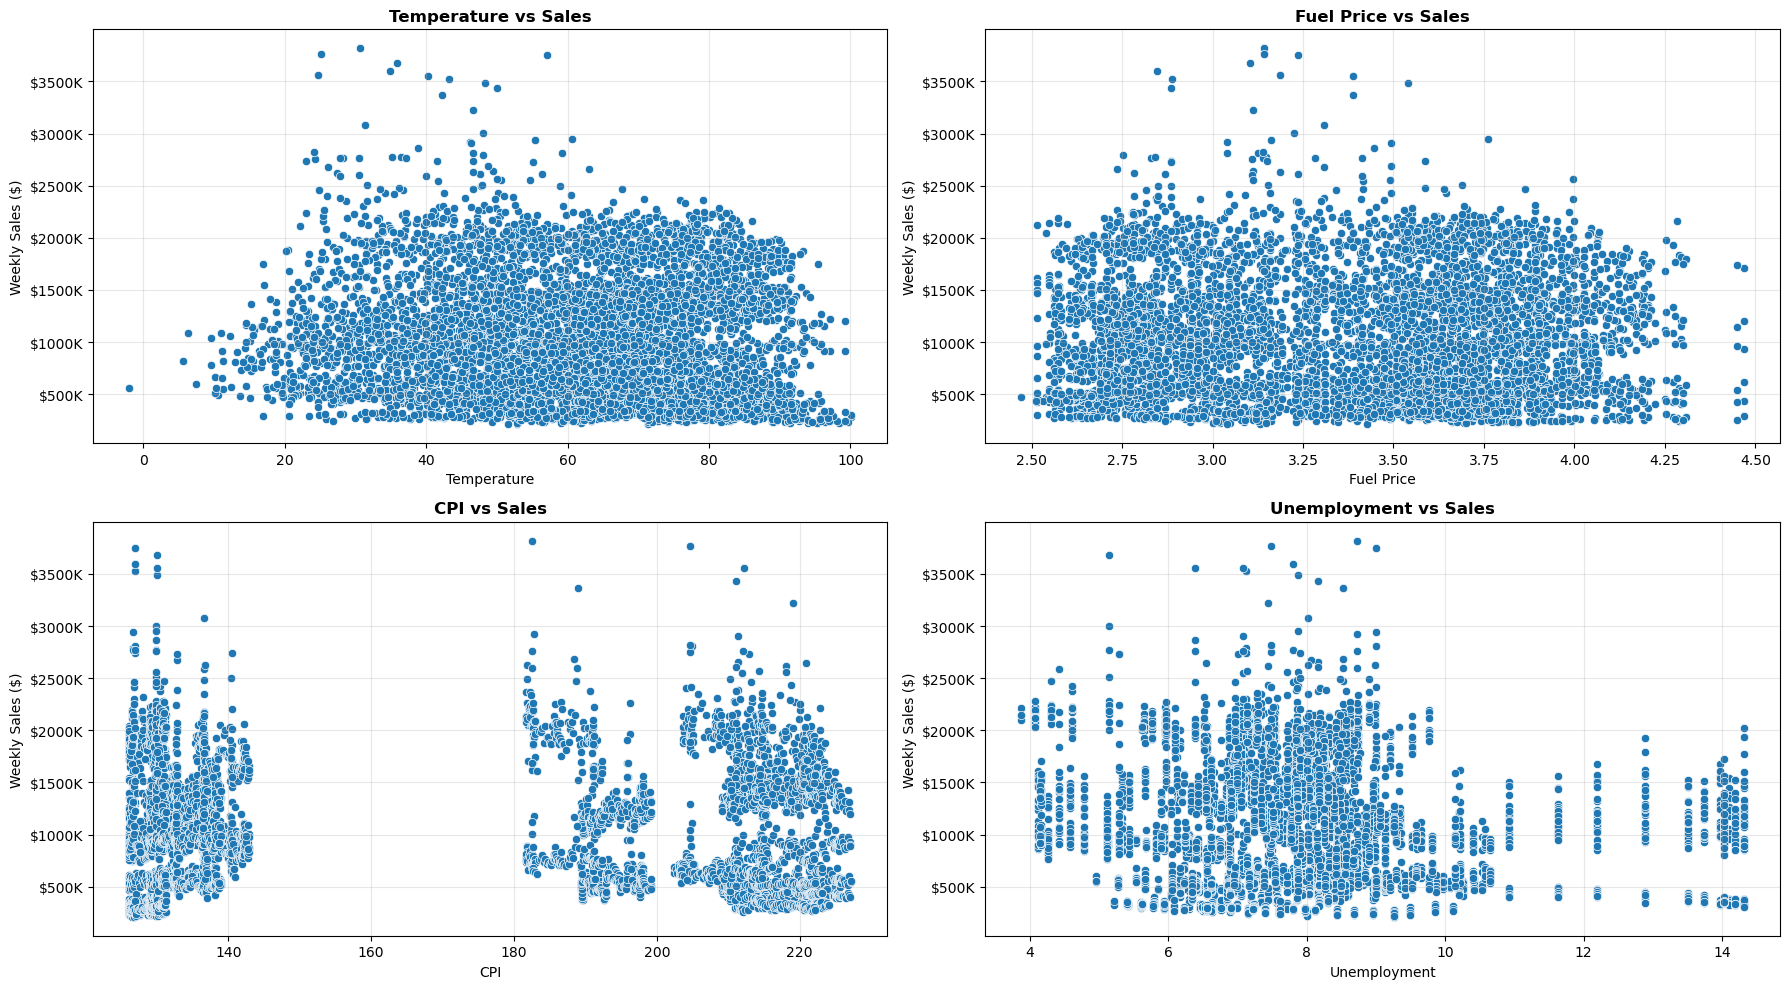

In [21]:
# Other Factors Analysis with Sales
fig, axes = plt.subplots(2, 2, figsize = (18, 10))

# Temperature vs Sales
sns.scatterplot(x = df['Temperature'], y = df['Weekly_Sales'], ax = axes[0, 0])
axes[0, 0].set_title("Temperature vs Sales", fontweight = 'bold')
axes[0, 0].set_xlabel("Temperature")
axes[0, 0].set_ylabel("Weekly Sales ($)")
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
axes[0, 0].grid(alpha = 0.3)

# Fuel Price vs Sales
sns.scatterplot(x = df['Fuel_Price'], y = df['Weekly_Sales'], ax = axes[0, 1])
axes[0, 1].set_title("Fuel Price vs Sales", fontweight = 'bold')
axes[0, 1].set_xlabel("Fuel Price")
axes[0, 1].set_ylabel("Weekly Sales ($)")
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
axes[0, 1].grid(alpha = 0.3)

# CPI vs Sales
sns.scatterplot(x = df['CPI'], y = df['Weekly_Sales'], ax = axes[1, 0])
axes[1, 0].set_title("CPI vs Sales", fontweight = 'bold')
axes[1, 0].set_xlabel("CPI")
axes[1, 0].set_ylabel("Weekly Sales ($)")
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
axes[1, 0].grid(alpha = 0.3)

# Unemployment vs Sales
sns.scatterplot(x = df['Unemployment'], y = df['Weekly_Sales'], ax = axes[1, 1])
axes[1, 1].set_title("Unemployment vs Sales", fontweight = 'bold')
axes[1, 1].set_xlabel("Unemployment")
axes[1, 1].set_ylabel("Weekly Sales ($)")
axes[1, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1e3):.0f}K'))
axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

- The scatterplots show that there no clear relationship between factors: Temperature, Fuel Price, CPI, Unemployment with Weekly Sales verifying their correlation statistics. 